# Dichtebasiertes Clustering von Netzüberwachungsstandorten mit PROC MODECLUS


## Zusammenfassung

Ein Stromverteilungsunternehmen verwendet PROC MODECLUS, um nichtparametrische,
dichtebasierte Cluster unter seinen Netzüberwachungsstandorten (Umspannwerke
und Abzweigsensoren) allein anhand ihrer Kartenkoordinaten zu finden. MODECLUS
schätzt eine Dichteoberfläche über die Standorte und behandelt Cluster als
Regionen hoher Dichte, die durch Bereiche geringer Dichte getrennt sind. Bei
90 simulierten Standorten und einem Gleichverteilungskern mit Radius 3 km
werden die drei dichten Versorgungsbereiche, die wir in die Daten eingebaut
haben, als die drei größten Cluster wiedergefunden (24, 24 und 21 Standorte),
während die verstreuten ländlichen Standorte in dünn besiedelte Regionen
fallen und sich in eigene Ein- und Zwei-Standort-Mikrocluster aufspalten.
Diese Gruppe isolierter Standorte ist das operative Ergebnis: eine
Kandidatenliste entlegener Anlagen für das Team der Investitionsplanung.


## Datenquellen

| Datensatz | Zeilen | Beschreibung |
|---------|------|-------------|
| `grid_sites` | 90 | Synthetische Standorte der elektrischen Verteilung, inline erzeugt mit `call streaminit(70531)` und `rand()`. Drei dichte Servicebereiche (Stadtkern, Vorstadt, Industrie) aus bivariaten Normalverteilungen um unterschiedliche Kartenmittelpunkte, sowie 22 verstreute ländliche Standorte, gleichverteilt über das gesamte Gebiet gezogen. |

| Variable | Typ | Beschreibung |
|----------|------|-------------|
| `site_id` | Num | Eindeutige Standort-Kennung (1-90). |
| `region` | Char | Planungslabel, das festhält, wie jeder Standort erzeugt wurde (Stadtkern, Vorstadt, Industrie, Ländlich); wird beim Clustering ausgeklammert. |
| `x_km`, `y_km` | Num | Standort in Kilometern auf dem Planungsraster des Unternehmens; die Clustering-Variablen. |
| `peak_load_mw` | Num | Beobachtete jährliche Spitzenlast (MW) am Standort; für die spätere Interpretation mitgeführt. |


# Dichtebasiertes Clustering von Netzüberwachungsstandorten

Ein regionales Stromverteilungsunternehmen betreibt ein Netz von
**Überwachungsstandorten** -- Umspannwerke und Abzweigsensoren -- verteilt über
sein Versorgungsgebiet. Die Planer möchten diese Standorte allein aufgrund
der Geografie zu natürlichen **Servicebereichen** gruppieren, ohne die Anzahl
der Gruppen vorzugeben, und **isolierte ländliche Anlagen** identifizieren,
die zu keinem dichten Bereich gehören.

`PROC MODECLUS` eignet sich hierfür gut: Es führt *nichtparametrisches,
dichtebasiertes* Clustering durch. Es schätzt eine Dichtefunktion über die
Standorte und behandelt dann Cluster als Regionen hoher Standortdichte,
getrennt durch Bereiche geringer Dichte. Spärliche Ausreißer landen in
eigenen winzigen Clustern, statt in einen Bereich aufgenommen zu werden --
genau das Verhalten, das wir zur Kennzeichnung entlegener Standorte wollen.

Dieses Notebook:
1. Erzeugt ein realistisches synthetisches Netzwerk von 90 Standorten.
2. Schätzt die Standortdichte mit einem **Gleichverteilungskern** und scannt
   den Glättungsradius `R=`, um zu bestätigen, dass die gefundenen Bereiche
   stabil sind.
3. Legt einen Arbeitsradius fest, schreibt einen `OUT=`-Datensatz mit der
   Dichte und dem Cluster-Label jedes Standorts und stellt das Ergebnis auf
   einer Karte dar.


## Schritt 1 -- Erzeugung eines synthetischen Netzwerks von Überwachungsstandorten

Wir simulieren 90 Standorte. Drei dichte **Servicebereiche** werden aus
bivariaten Normalverteilungen um unterschiedliche Kartenmittelpunkte gezogen
(Stadtkern nahe (12, 30), Vorstadt nahe (30, 15), Industrie nahe (20, 42)),
was kompakte Blöcke hoher Dichte mit 24, 24 und 20 Standorten ergibt. Eine
vierte Gruppe von 22 **ländlichen** Standorten wird gleichverteilt über das
gesamte Gebiet gezogen, was die spärlichen, verstreuten Standorte erzeugt,
die ein Versorgungsunternehmen als isoliert betrachten würde.

Das `region`-Label hält fest, wie jeder Standort erzeugt wurde; wir klammern
es beim Clustering absichtlich **aus**, damit MODECLUS die Struktur allein
aus den Koordinaten wiederentdeckt. `peak_load_mw` wird für die spätere
Interpretation mitgeführt.


In [1]:
DATEN grid_sites;
   AUFRUFEN streaminit(70531);
   LÄNGE region $ 16;

   /* Dichter Stadtkern-Servicebereich */
   AUSFÜHRUNG site_id = 1 BIS 24;
      region = 'Stadtkern';
      x_km = 12 + rand('normal') * 1.3;
      y_km = 30 + rand('normal') * 1.3;
      peak_load_mw = 4.5 + rand('normal') * 0.6;
      AUSGABE;
   ENDE;

   /* Vorstadt-Bereich */
   AUSFÜHRUNG site_id = 25 BIS 48;
      region = 'Vorstadt';
      x_km = 30 + rand('normal') * 1.6;
      y_km = 15 + rand('normal') * 1.6;
      peak_load_mw = 2.8 + rand('normal') * 0.5;
      AUSGABE;
   ENDE;

   /* Industriebereich (hoehere Spitzenlast) */
   AUSFÜHRUNG site_id = 49 BIS 68;
      region = 'Industrie';
      x_km = 20 + rand('normal') * 1.4;
      y_km = 42 + rand('normal') * 1.4;
      peak_load_mw = 6.1 + rand('normal') * 0.8;
      AUSGABE;
   ENDE;

   /* Verstreute laendliche Standorte (spaerlich, geringe Last) */
   AUSFÜHRUNG site_id = 69 BIS 90;
      region = 'Ländlich';
      x_km = 2 + rand('uniform') * 46;
      y_km = 2 + rand('uniform') * 50;
      peak_load_mw = 0.8 + rand('uniform') * 1.2;
      AUSGABE;
   ENDE;
AUSFÜHREN;

TITEL 'Synthetische Netzüberwachungsstandorte';
PROZEDUR MEANS DATEN=grid_sites n mean std MIN MAX maxdec=2;
   KLASSE region;
   VAR x_km y_km peak_load_mw;
   BEZEICHNUNG region="Region" x_km="Rechtswert (km)" y_km="Hochwert (km)" peak_load_mw="Spitzenlast (MW)";
AUSFÜHREN;


                                         Synthetische Netzüberwachungsstandorte                                         

                                                  The MEANS Procedure

                                        Analysis Variable : x_km Rechtswert (km)

        Region             N Obs           Mean        Std Dev        Minimum        Maximum
        ------------------------------------------------------------------------------------
        Industrie             20          20.36           0.96          18.52          21.53
        Ländlich              22          29.79          10.62          11.06          47.45
        Stadtkern             24          12.07           1.34           8.65          14.42
        Vorstadt              24          29.96           1.73          26.51          33.60
        ------------------------------------------------------------------------------------

                                         Analysis Variable : y_km Hochwer


NOTE: DATA grid_sites


NOTE: Wrote grid_sites (90 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: Option TITLE changed to Synthetische Netzüberwachungsstandorte.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


Die Mittelwerte bestätigen drei enge Bereiche und eine diffuse Gruppe. Die
drei dichten Regionen haben kleine Standardabweichungen der Koordinaten
(etwa 1-1,7 km auf jeder Achse) um klar getrennte Zentren, während sich die
ländliche Gruppe über das gesamte Raster verteilt (Standardabweichungen über
10 km auf beiden Achsen). Auch die Spitzenlast trennt die Bereiche --
Industrie-Standorte liegen im Schnitt bei etwa 6 MW, Stadtkern bei etwa
4,6 MW, Vorstadt bei etwa 2,7 MW und ländliche Standorte bei etwa 1,5 MW --
was nützlichen Kontext liefert, sobald die geografischen Cluster vorliegen.


## Schritt 2 -- Dichte-Clustering mit Gleichverteilungskern und Radius-Scan

Die Dichteschätzung mit Gleichverteilungskern verwendet einen **Radius `R=`**:
Jeder Standort innerhalb von `R` Kilometern trägt zur lokalen Dichte eines
Standorts bei. Ein kleiner `R`-Wert ergibt eine wackelige Dichte, die das
Gebiet fragmentiert; ein großer Wert glättet zu stark und verschmilzt
Bereiche. Ein SAS-Experte vertraut nie einem einzelnen Wert -- er scannt
einen Bereich von Radien und sucht nach einer **stabilen** Clusteranzahl, bei
der die dichten Bereiche bestehen bleiben, während nur die Anzahl der
verstreuten Einzelstandorte schwankt.

Hier wählt `M=1` die Clustering-Methode 1 (die nichtparametrische
Standardmethode), und wir fordern in einem Aufruf Radien `R=2,5 bis 4 in
Schritten von 0,5` an. MODECLUS führt die Analyse einmal je Radius aus und
meldet die Clusteranzahl für jeden. `SHORT` unterdrückt die ausführlichen
Statistiken je Cluster.


In [2]:
TITEL 'Dichte-Clustering der Netzstandorte (Gleichverteilungskern)';
title2 'Radius-Scan R = 2.5 bis 4.0 km';

PROZEDUR modeclus DATEN=grid_sites m=1 r=2.5 BIS 4 NACH 0.5 short;
   VAR x_km y_km;
   id site_id;
AUSFÜHREN;


                              Dichte-Clustering der Netzstandorte (Gleichverteilungskern)                               
                                             Radius-Scan R = 2.5 bis 4.0 km                                             


                                                 The MODECLUS Procedure                                                 

  Method: 1
  Number of Observations: 90
  Number of Variables: 2
  Variables: x_km y_km

  Density Estimation: Bandwidth=2.5000
  Number of Clusters: 23

  Density Estimation: Bandwidth=3.0000
  Number of Clusters: 22

  Density Estimation: Bandwidth=3.5000
  Number of Clusters: 19

  Density Estimation: Bandwidth=4.0000
  Number of Clusters: 18





NOTE: Option TITLE changed to Dichte-Clustering der Netzstandorte (Gleichverteilungskern).
NOTE: Option TITLE2 changed to Radius-Scan R = 2.5 bis 4.0 km.
NOTE: PROC MODECLUS data=grid_sites method=1

NOTE: Using Python/scipy for density-based clustering
NOTE: Density estimation: 23 Cluster(s) found. Bandwidth=2.5000 Mode-based Clustering complete.
NOTE: Density estimation: 22 Cluster(s) found. Bandwidth=3.0000 Mode-based Clustering complete.
NOTE: Density estimation: 19 Cluster(s) found. Bandwidth=3.5000 Mode-based Clustering complete.
NOTE: Density estimation: 18 Cluster(s) found. Bandwidth=4.0000 Mode-based Clustering complete.
NOTE: PROC MODECLUS: 90 observations, 2 variables, method=1


Die Clusteranzahl bewegt sich über den Scan hinweg nur sanft -- 23 Cluster
bei `R=2,5`, 22 bei `R=3,0`, 19 bei `R=3,5` und 18 bei `R=4,0`. Die hohen
Rohzahlen stammen von den verstreuten ländlichen Standorten: Jeder isolierte
Standort liegt in seiner eigenen spärlichen Nachbarschaft und bildet einen
Ein-Standort-Cluster, sodass die meisten der 18-23 "Cluster" Einzelstandorte
sind. Was darunter konstant bleibt, ist die Struktur, auf die es ankommt --
die drei dichten Bereiche bleiben bei jedem Radius drei große, klar
getrennte Cluster. Mit wachsendem `R` verschmelzen einige der verstreuten
Einzelstandorte mit einem Nachbarn oder einem nahegelegenen Bereich, weshalb
die Gesamtzahl langsam abnimmt, statt wild zu schwanken. Diese Stabilität
ist das Signal, dass die Drei-Bereiche-Lösung real ist und kein Artefakt
einer einzelnen Bandbreite.


## Schritt 3 -- Endgültige Cluster-Lösung für die Kartendarstellung

Nachdem wir gesehen haben, dass die drei Bereiche über den Scan hinweg
stabil sind, legen wir einen einzelnen Arbeitsradius (`R=3` km) fest und
fordern die Option **ALL** für die vollständige Anzeige je Cluster an, plus
**OUT=**, um die ursprünglichen Koordinaten zusammen mit der
`DENSITY`-Schätzung und der `CLUSTER`-Zuordnung zu schreiben, damit wir das
Ergebnis auf einer Karte darstellen können. Cluster werden nach absteigender
Modus-Dichte nummeriert, sodass die dichtesten Bereiche die Cluster 1, 2 und
3 sind und die spärlichen Standorte die höheren Nummern erhalten.


In [3]:
TITEL 'Endgültige dichtebasierte Cluster-Lösung';
title2 'Gleichverteilungskern, R = 3 km';

PROZEDUR modeclus DATEN=grid_sites m=1 r=3 out=join_out ALL;
   VAR x_km y_km;
   id site_id;
AUSFÜHREN;


                                        Endgültige dichtebasierte Cluster-Lösung                                        
                                            Gleichverteilungskern, R = 3 km                                             


                                                 The MODECLUS Procedure                                                 

  Method: 1
  Number of Observations: 90
  Number of Variables: 2
  Variables: x_km y_km

  Density Estimation: Bandwidth=3.0000
  Number of Clusters: 22

  Cluster Summary
  ---------------------------------------------------------------
  Cluster   N   Mode   Mode Density
  ---------------------------------------------------------------
        1   24           5      0.009038
        2   24          46      0.007860
        3   21          56      0.007860
        4    3          83      0.001179
        5    1          29      0.000393
        6    1          69      0.000393
        7    1          70      0.000393
      


NOTE: Option TITLE changed to Endgültige dichtebasierte Cluster-Lösung.
NOTE: Option TITLE2 changed to Gleichverteilungskern, R = 3 km.
NOTE: PROC MODECLUS data=grid_sites method=1

NOTE: Using Python/scipy for density-based clustering
NOTE: Density estimation: 22 Cluster(s) found. Bandwidth=3.0000 Mode-based Clustering complete.
NOTE: PROC MODECLUS: 90 observations, 2 variables, method=1


Die Cluster-Zusammenfassung macht die Struktur deutlich. Die `R=3`-Lösung
liefert **22 Cluster**, die jedoch stark nach Dichte gestuft sind:

- **Cluster 1** -- 24 Standorte, Modus-Dichte etwa 0,0090 (der
  Stadtkern-Bereich).
- **Cluster 2** -- 24 Standorte, Modus-Dichte etwa 0,0079 (der
  Vorstadt-Bereich).
- **Cluster 3** -- 21 Standorte, Modus-Dichte etwa 0,0079 (der
  Industrie-Bereich; er nimmt einen ländlichen Standort auf, der zufällig an
  seinem Rand liegt).
- **Cluster 4-22** -- eine Drei-Standort-Gruppe und achtzehn
  Einzelstandort-Cluster, alle bei einer Modus-Dichte von etwa 0,0004, rund
  zwanzigmal spärlicher als die Bereiche.

Die drei dichten Bereiche vereinen 69 der 90 Standorte auf sich; die
verbleibenden 21 Standorte sind die verstreuten ländlichen Anlagen, jede für
sich allein oder fast allein in einer Nachbarschaft geringer Dichte. Die
Dichte -- nicht eine vorgegebene Clusteranzahl -- zieht die Grenze zwischen
einem Servicebereich und einem isolierten Standort.


## Schritt 4 -- Die Cluster auf der Karte darstellen

Wir kennzeichnen jeden Standort danach, ob er in einem der drei dichten
Bereiche (`cluster <= 3`) oder in einem spärlichen Mikrocluster gelandet
ist, und stellen dann jeden Standort an seinen Kartenkoordinaten dar,
eingefärbt nach diesem Status. Das ist die Sicht des Planers: dichte
Bereiche, die als Servicegebiete zu verwalten sind, und isolierte Standorte,
die für eine gesonderte Behandlung zu kennzeichnen sind.


                                Wiedergefundene Servicebereiche und isolierte Standorte                                 
                             Dichtebasiertes Clustering mit Gleichverteilungskern, R = 3 km                             




NOTE: DATA mapped


NOTE: Read 90 rows from join_out.
NOTE: Wrote mapped (90 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: Option TITLE changed to Wiedergefundene Servicebereiche und isolierte Standorte.
NOTE: Option TITLE2 changed to Dichtebasiertes Clustering mit Gleichverteilungskern, R = 3 km.
NOTE: PROC SGPLOT data=mapped

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


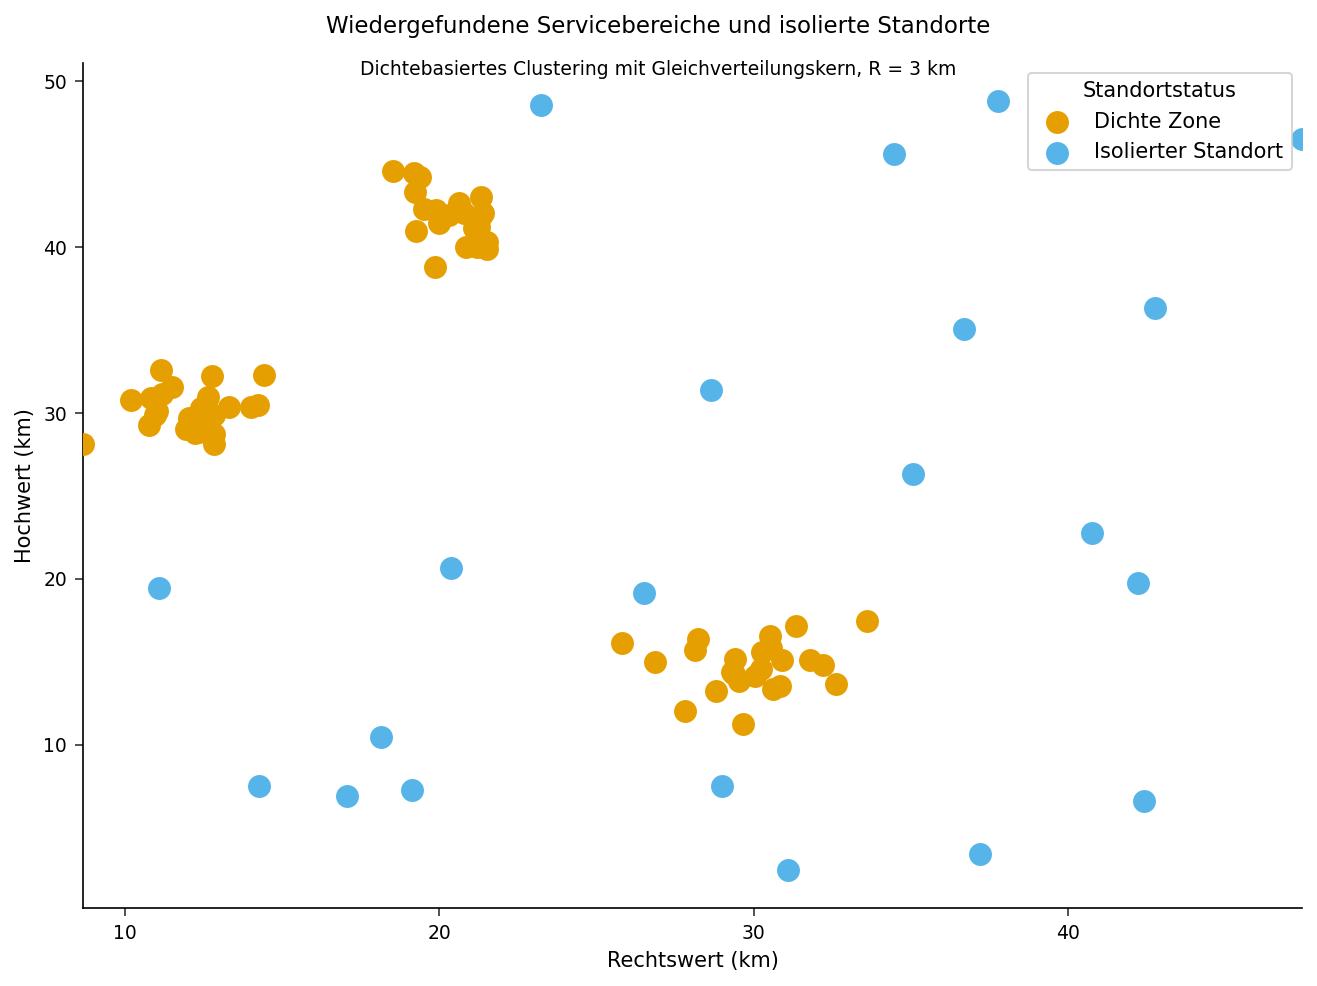

In [4]:
DATEN mapped;
   FESTLEGEN join_out;
   LÄNGE status $ 24;
   WENN CLUSTER <= 3 DANN status = 'Dichte Zone';
   SONST status = 'Isolierter Standort';
AUSFÜHREN;

TITEL 'Wiedergefundene Servicebereiche und isolierte Standorte';
title2 'Dichtebasiertes Clustering mit Gleichverteilungskern, R = 3 km';
PROZEDUR SGPLOT DATEN=mapped;
   SCATTER x=x_km y=y_km / GROUP=status markerchar=CLUSTER
                           MARKERATTRS=(size=10);
   XAXIS BEZEICHNUNG='Rechtswert (km)';
   YAXIS BEZEICHNUNG='Hochwert (km)';
   keylegend / TITEL='Standortstatus';
AUSFÜHREN;

TITEL;


## Interpretation der Ergebnisse

**Was MODECLUS gefunden hat.** Allein anhand von `(x_km, y_km)` findet das
Verfahren die drei dichten Servicebereiche wieder, die wir in die Daten
eingebaut haben -- die Blöcke Stadtkern, Vorstadt und Industrie -- als die
drei größten, dichtesten Cluster (24, 24 und 21 Standorte). Die verstreuten
ländlichen Standorte, gleichverteilt über das Gebiet gezogen, fallen in
spärliche Regionen und spalten sich in eigene Ein- und
Zwei-Standort-Cluster auf, statt in einen Bereich aufgenommen zu werden.
Auf der Karte sind sie die Punkte, die von den drei engen Blöcken getrennt
sind. Diese isolierte Gruppe ist das operative Ergebnis: eine
Kandidatenliste entlegener Anlagen für das Team der Investitionsplanung.

**Warum der Glättungs-Scan wichtig ist.** Kein einzelner `R`-Wert ist
maßgeblich für nichtparametrisches dichtebasiertes Clustering. Der Scan
`R=2,5 bis 4 in Schritten von 0,5` erlaubt uns zu bestätigen, dass die
Bereiche über die Glättungsstufen hinweg *stabil* sind und kein Artefakt
einer einzelnen Bandbreite. Über den Scan hinweg bewegt sich die
Clusteranzahl nur von 23 auf 18, und die Änderung liegt ausschließlich in
der Anzahl der verstreuten Einzelstandorte -- die drei dichten Bereiche
bleiben durchgehend bestehen. Wo die Struktur so stabil blieb, haben wir
eine verteidigungsfähige Lösung; hätte die Zahl wild geschwankt, wäre die
Struktur fragil gewesen und sollte keine Investitionsentscheidungen leiten.

**Die Dichte staffelt das Ergebnis.** Da Cluster nach absteigender
Modus-Dichte nummeriert werden, ist die Trennung zwischen Bereichen und
isolierten Standorten quantitativ, nicht willkürlich: Die drei Bereiche
liegen nahe einer Modus-Dichte von 0,008-0,009, während jeder isolierte
Standort bei etwa 0,0004 liegt, rund zwanzigmal spärlicher. Ein Planer kann
eine Dichteschwelle festlegen und die isolierten Anlagen direkt aus den
Spalten `CLUSTER` und `DENSITY` von `join_out` ablesen.

**Praktischer Nutzen.** Der Datensatz `join_out` gibt jedem Standort eine
Dichte und ein Cluster-Label, das nachgelagerte Arbeiten anstoßen kann --
Dimensionierung von Trupps und Ersatzteilen je Servicebereich, Planung von
Inspektionsrouten oder Priorisierung der Netzertüchtigung im dichten
Industrie-Cluster (höchste `peak_load_mw`, etwa 6 MW), während die
isolierten ländlichen Standorte für eine gesonderte, seltenere Wartung
eingeplant werden.

*Hinweis zu synthetischen Daten:* Koordinaten und Lasten werden mit einem
festen Seed simuliert (`call streaminit(70531)`), sodass das Notebook
vollständig offline reproduzierbar ist; bei echten Versorgungsdaten würden
Sie vermessene Standortkoordinaten und gemessene Spitzenlasten einsetzen.
Die genauen Clusterzahlen hängen vom Zufallszug und vom gewählten Radius ab.
